<a href="https://colab.research.google.com/github/bubai-jkc/leaf-disease_unet_resnet50_resnet101/blob/main/unet_leaf_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!kaggle datasets download -d fakhrealam9537/leaf-disease-segmentation-dataset
import zipfile
zip_ref = zipfile.ZipFile('/content/leaf-disease-segmentation-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

Dataset URL: https://www.kaggle.com/datasets/fakhrealam9537/leaf-disease-segmentation-dataset
License(s): CC0-1.0
 93% 466M/503M [00:01<00:00, 395MB/s]
100% 503M/503M [00:01<00:00, 459MB/s]


Epoch [1/25] - Loss: 0.4062 - mIoU: 0.3826
Epoch [2/25] - Loss: 0.2972 - mIoU: 0.4546
Epoch [3/25] - Loss: 0.2619 - mIoU: 0.4810
Epoch [4/25] - Loss: 0.2410 - mIoU: 0.5098
Epoch [5/25] - Loss: 0.2219 - mIoU: 0.5299
Epoch [6/25] - Loss: 0.2081 - mIoU: 0.5532
Epoch [7/25] - Loss: 0.1957 - mIoU: 0.5732
Epoch [8/25] - Loss: 0.1883 - mIoU: 0.5809
Epoch [9/25] - Loss: 0.1750 - mIoU: 0.6012
Epoch [10/25] - Loss: 0.1656 - mIoU: 0.6134
Epoch [11/25] - Loss: 0.1630 - mIoU: 0.6220
Epoch [12/25] - Loss: 0.1535 - mIoU: 0.6352
Epoch [13/25] - Loss: 0.1516 - mIoU: 0.6375
Epoch [14/25] - Loss: 0.1409 - mIoU: 0.6542
Epoch [15/25] - Loss: 0.1377 - mIoU: 0.6592
Epoch [16/25] - Loss: 0.1341 - mIoU: 0.6605
Epoch [17/25] - Loss: 0.1269 - mIoU: 0.6738
Epoch [18/25] - Loss: 0.1235 - mIoU: 0.6787
Epoch [19/25] - Loss: 0.1231 - mIoU: 0.6797
Epoch [20/25] - Loss: 0.1222 - mIoU: 0.6812
Epoch [21/25] - Loss: 0.1095 - mIoU: 0.7004
Epoch [22/25] - Loss: 0.1063 - mIoU: 0.7058
Epoch [23/25] - Loss: 0.1051 - mIoU: 0.70

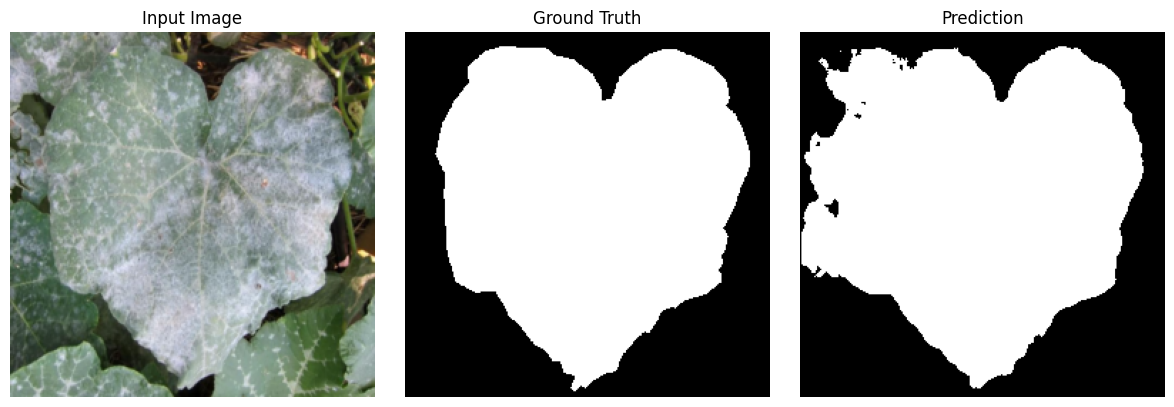

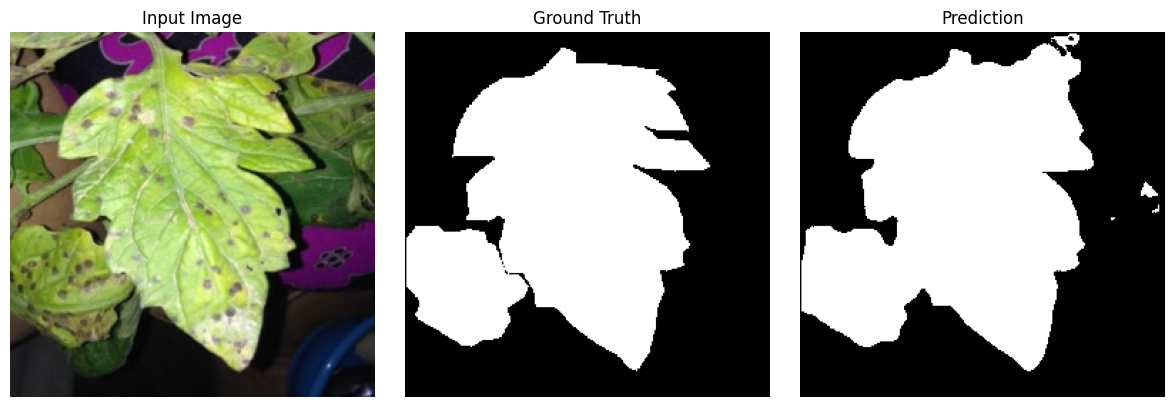

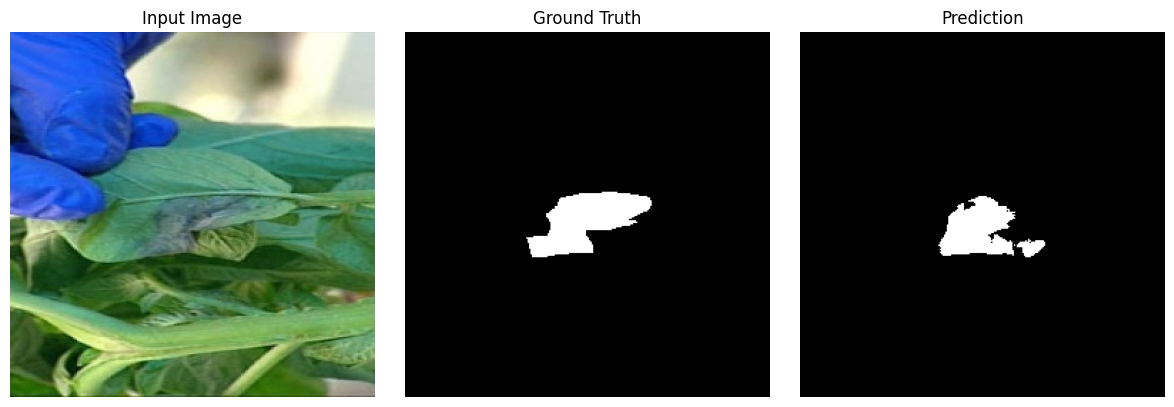

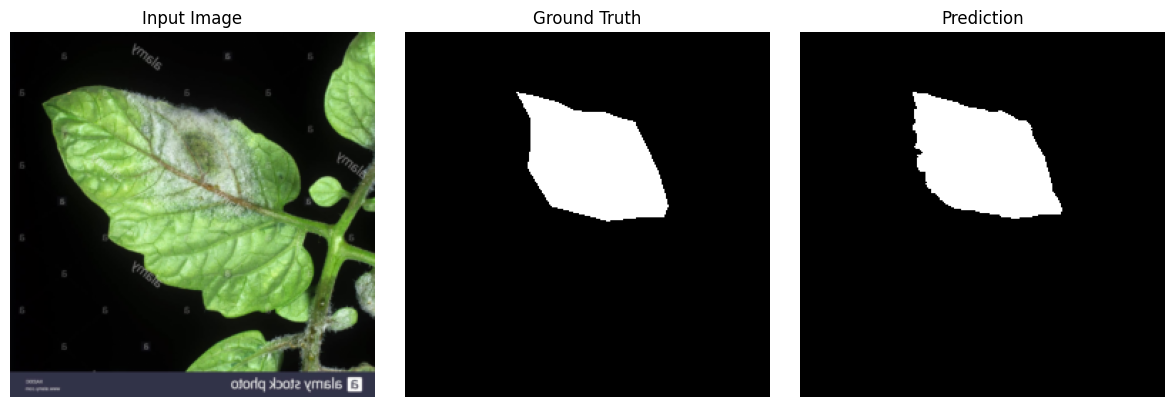

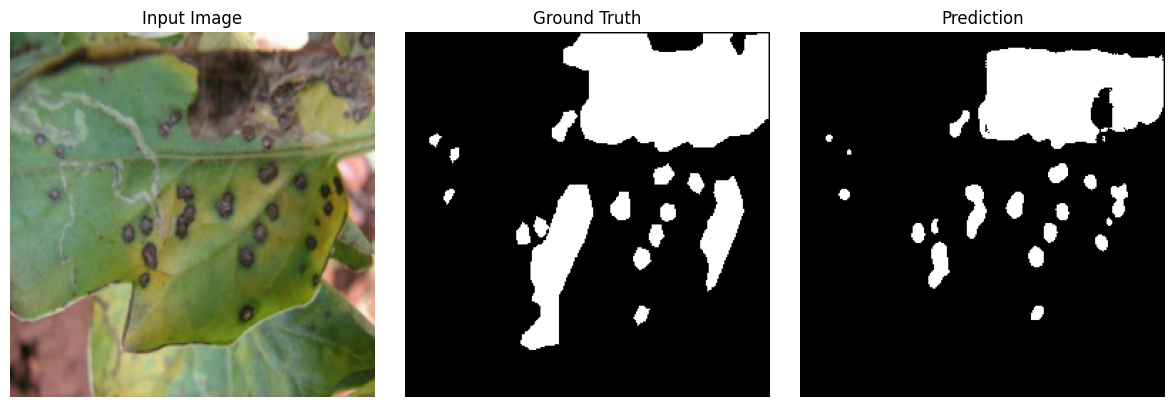

In [ ]:

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class LeafDiseaseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.images_dir = os.path.join(root_dir, "images")
        self.masks_dir  = os.path.join(root_dir, "masks")
        self.transform = transform

        self.image_files = sorted(os.listdir(self.images_dir))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]

        img_path  = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, img_name.replace(".jpg", ".png"))

        image = Image.open(img_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)

            mask = transforms.Compose([
                transforms.Resize((256, 256), interpolation=Image.NEAREST),
                transforms.ToTensor()
            ])(mask)

            mask = (mask > 0).float()

        return image, mask


DATASET_PATH = "/content/aug_data/aug_data"

image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

dataset = LeafDiseaseDataset(DATASET_PATH, transform=image_transform)
data_loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.inc   = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.outc = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


def mean_iou(preds, masks, eps=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean()


num_epochs = 25

for epoch in range(num_epochs):
    model.train()

    epoch_loss = 0.0
    epoch_iou  = 0.0

    for images, masks in data_loader:
        images = images.to(device)
        masks  = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        epoch_iou  += mean_iou(outputs, masks).item() * images.size(0)

    epoch_loss /= len(data_loader.dataset)
    epoch_iou  /= len(data_loader.dataset)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"- Loss: {epoch_loss:.4f} "
        f"- mIoU: {epoch_iou:.4f}"
    )



def visualize_segmentation(model, dataloader, device, num_samples=3):
    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks  = masks.to(device)

            outputs = model(images)
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()

            for i in range(images.size(0)):
                if shown >= num_samples:
                    return

                img  = images[i].cpu().permute(1, 2, 0)
                gt   = masks[i].cpu().squeeze()
                pred = preds[i].cpu().squeeze()

                img = img * torch.tensor([0.229, 0.224, 0.225]) + \
                      torch.tensor([0.485, 0.456, 0.406])
                img = img.clamp(0, 1)

                plt.figure(figsize=(12, 4))

                plt.subplot(1, 3, 1)
                plt.imshow(img)
                plt.title("Input Image")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(gt, cmap="gray")
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(pred, cmap="gray")
                plt.title("Prediction")
                plt.axis("off")

                plt.tight_layout()
                plt.show()
                shown += 1


visualize_segmentation(
    model=model,
    dataloader=data_loader,
    device=device,
    num_samples=5
)
